In [1]:
print("Adiós Colab, hola Pienza")

Adiós Colab, hola Pienza


In [11]:
# ==============================================================================
# CELDA 0: PIENZA COMMAND CENTER - BOOTSTRAP (CODESPACES / STREAMLIT READY)
# ==============================================================================
import os
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. AUTENTICACIÓN SOSTENIBLE (Modo Local/Producción)
print("🔐 Autenticando identidad en Google Cloud...")
# NOTA: Para que esto funcione, necesitas tu archivo JSON de Service Account de GCP.
# Reemplaza la ruta con la ubicación real de tu archivo JSON en el Codespace.
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/workspaces/pienza/observatory/service-account.json" 
print("✅ Credenciales configuradas en el entorno.")

# 2. CONFIGURACIÓN DEL PROYECTO
PROJECT_ID   = '645009831643'
DATASET_CORE = 'pienza_mini'
DATASET_BIG  = 'pienza_big'

# 3. INICIALIZACIÓN DE CLIENTE (La puerta de entrada a tus datos)
print(f"📡 Conectando al ecosistema BigQuery (Project: {PROJECT_ID})...")
try:
    client = bigquery.Client(project=PROJECT_ID)
    print("✅ Cliente BigQuery conectado con éxito.")
except Exception as e:
    print(f"❌ Error de conexión. ¿Ya subiste tu archivo JSON? Detalle: {e}")

# 4. VISUAL CANON (OPUS LAB THEME) - Preparado para tus gráficas
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY, 'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT, 'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold', 'font.family': 'sans-serif'
})

print("\n--- SYSTEM READY: BQ Ecosistema Operativo ---")

🔐 Autenticando identidad en Google Cloud...
✅ Credenciales configuradas en el entorno.
📡 Conectando al ecosistema BigQuery (Project: 645009831643)...
✅ Cliente BigQuery conectado con éxito.

--- SYSTEM READY: BQ Ecosistema Operativo ---


⏳ Extrayendo datos desde BigQuery...


/usr/local/python/3.12.1/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


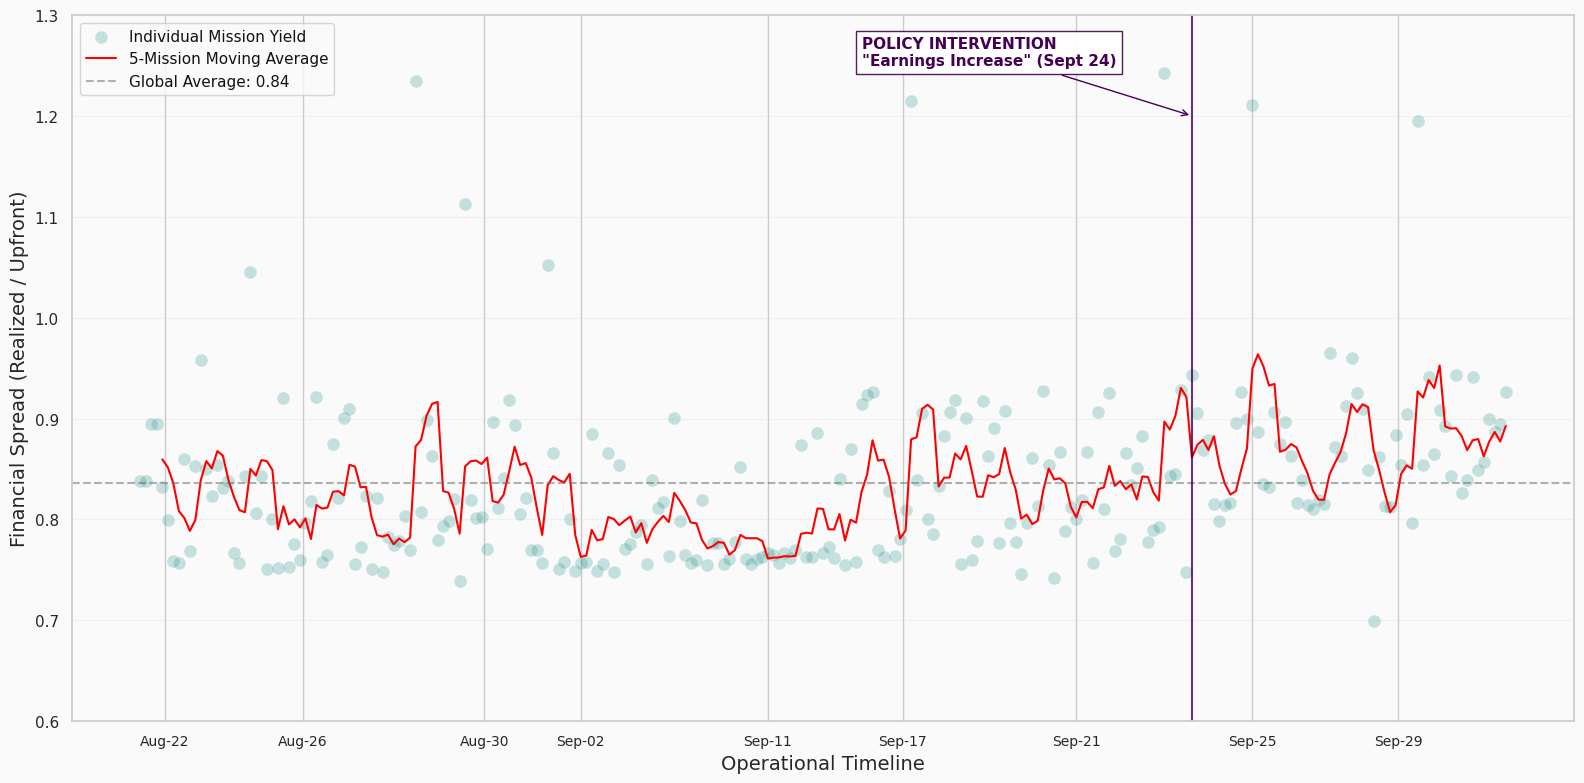


📊 KPI Summary:
   Global Mean Spread: 0.8361
   Realized Yield Lift (%): 6.9098


In [12]:
# ==============================================================================
# CELL 2: PHASE 1 - FINANCIAL STABILITY & POLICY INTERVENTION AUDIT (BQ VERSION)
# ==============================================================================

# --- 1. DATA INGESTION (BigQuery SQL) ---
query_stability = f"""
SELECT
    DATE(o.offer_timestamp) AS session_date,
    o.offer_id,
    v.spread_percentage     AS financial_spread
FROM `{PROJECT_ID}.{DATASET_CORE}.v_mission_dossier` v
JOIN `{PROJECT_ID}.{DATASET_CORE}.offers` o ON v.offer_id = o.offer_id
WHERE v.realized_fare IS NOT NULL
"""

print("⏳ Extrayendo datos desde BigQuery...")
df_dated = client.query(query_stability).to_dataframe()
df_dated['session_date'] = pd.to_datetime(df_dated['session_date'])

# --- 2. DATA PREPARATION ---
df_dated = df_dated.sort_values(['session_date', 'offer_id'], ascending=True)
df_dated['mission_rank'] = range(1, len(df_dated) + 1)

window_size = 5
df_dated['spread_ma'] = df_dated['financial_spread'].rolling(window=window_size).mean()

# --- 3. EVENT DEFINITION ---
event_date = pd.to_datetime('2025-09-24')
event_rank = df_dated[df_dated['session_date'] >= event_date]['mission_rank'].min()

# --- 4. PLOTTING ---
plt.figure(figsize=(16, 8))

plt.scatter(df_dated['mission_rank'], df_dated['financial_spread'],
            alpha=0.25, color=OPUS_TEAL, s=85, edgecolors='white', linewidth=0.5,
            label='Individual Mission Yield')

plt.plot(df_dated['mission_rank'], df_dated['spread_ma'],
         color='red', linewidth=1.5, label=f'{window_size}-Mission Moving Average')

global_mean = df_dated['financial_spread'].mean()
plt.axhline(global_mean, color='#666666', linestyle='--', alpha=0.5, label=f'Global Average: {global_mean:.2f}')

plt.axvline(event_rank, color=OPUS_PURPLE, linestyle='-', linewidth=1.5, alpha=0.8)
plt.annotate('POLICY INTERVENTION\n"Earnings Increase" (Sept 24)',
             xy=(event_rank, 1.2), xytext=(event_rank - 60, 1.25),
             arrowprops=dict(arrowstyle='->', color=OPUS_PURPLE),
             fontsize=11, fontweight='bold', color=OPUS_PURPLE,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor=OPUS_PURPLE))

date_labels = df_dated.groupby(df_dated['session_date'].dt.strftime('%b-%d'))['mission_rank'].median().reset_index()
plt.xticks(date_labels['mission_rank'][::4], date_labels['session_date'][::4], fontsize=10)

plt.ylim(0.6, 1.3)
plt.ylabel("Financial Spread (Realized / Upfront)", fontsize=14)
plt.xlabel("Operational Timeline", fontsize=14)
plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# --- 5. FINAL STATISTICS (Preparadas para UI) ---
pre_event = df_dated[df_dated['session_date'] < event_date]['financial_spread'].mean()
post_event = df_dated[df_dated['session_date'] >= event_date]['financial_spread'].mean()
yield_lift = ((post_event/pre_event)-1)*100

# Guardamos los KPIs en un diccionario (útil para cuando migremos a Streamlit)
kpis_phase1 = {
    "Global Mean Spread": global_mean,
    "Realized Yield Lift (%)": yield_lift
}

print("\n📊 KPI Summary:")
for key, value in kpis_phase1.items():
    print(f"   {key}: {value:.4f}")

In [4]:
# Reemplaza con tu client de BQ
table = client.get_table("pienza_mini.v_mission_dossier")
for field in table.schema:
    print(field.name)

offer_id
trip_id_legacy
trip_date
duration_to_pickup_sec
duration_waiting_sec
duration_trip_sec
total_engagement_duration_sec
upfront_fare
realized_fare
spread_percentage
eph_on_ride
eph_total_time


In [5]:
# --- SANDBOX SQL TEST ---
# Probamos la query con los nombres de columnas EXACTOS que me diste
test_query = """
SELECT
    v.spread_percentage AS financial_spread,
    (v.duration_trip_sec / NULLIF(o.est_trip_time_sec, 0)) AS time_spread
FROM `645009831643.pienza_mini.v_mission_dossier` v
JOIN `645009831643.pienza_mini.offers` o ON v.offer_id = o.offer_id
WHERE o.est_trip_time_sec > 0
  AND v.realized_fare IS NOT NULL
LIMIT 10
"""

df_test = client.query(test_query).to_dataframe()
print("✅ QUERY EXITOSA. Datos recuperados:")
display(df_test.head())

/usr/local/python/3.12.1/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✅ QUERY EXITOSA. Datos recuperados:


,financial_spread,time_spread
0,0.894573,0.805952
1,0.799761,0.782609
2,0.758941,1.044253
3,0.756746,0.979545
4,0.853261,1.000000


⏳ Extrayendo datos desde BigQuery...


/usr/local/python/3.12.1/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


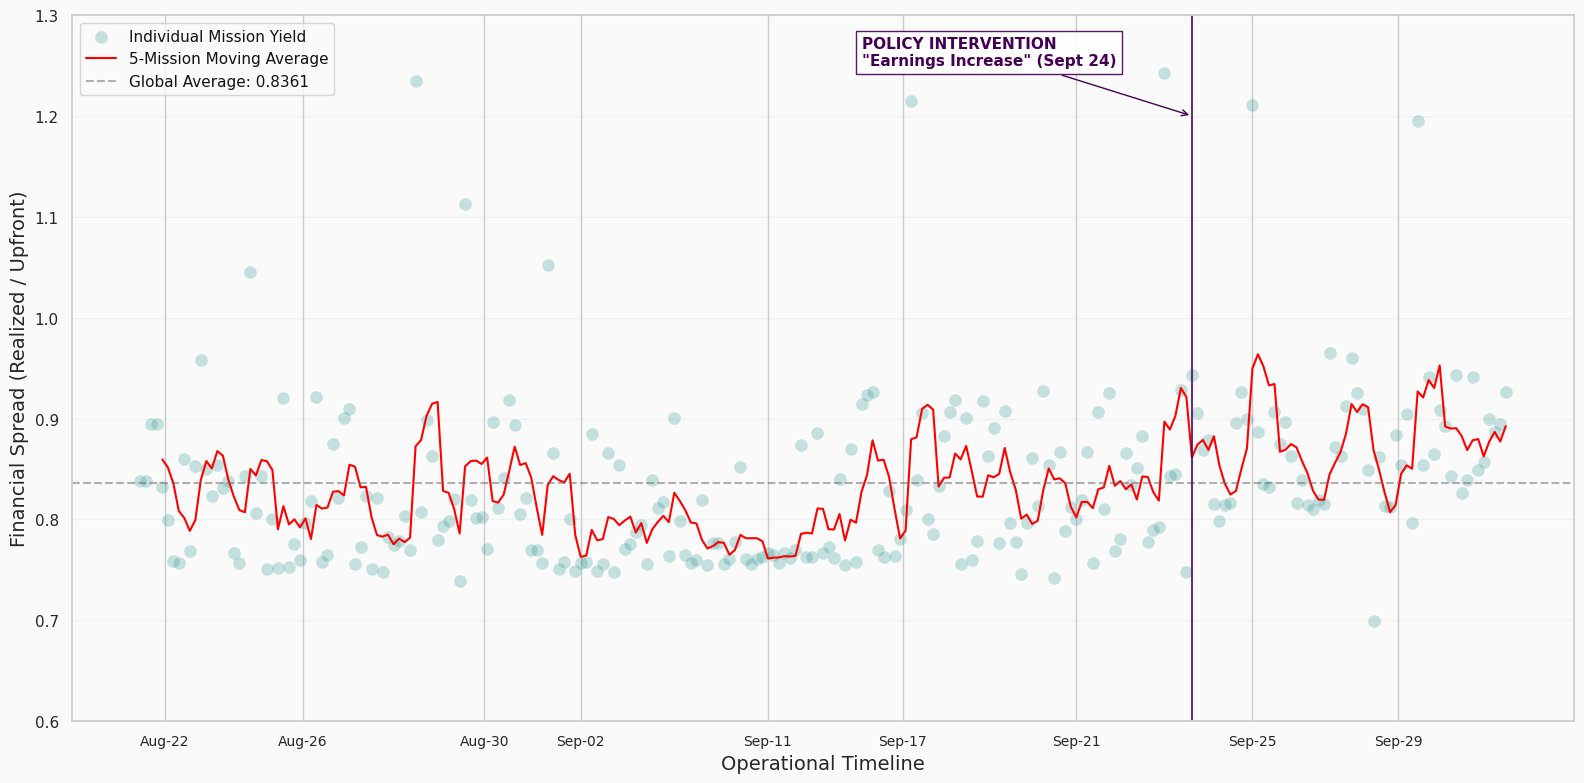

📊 GLOBAL MEAN SPREAD:        0.8361
📈 REALIZED YIELD LIFT:       6.91%


In [6]:
# ==============================================================================
# CELL 2: PHASE 1 - FINANCIAL STABILITY & POLICY INTERVENTION AUDIT (BQ VERSION)
# ==============================================================================

# --- 1. DATA INGESTION (BigQuery SQL) ---
# Hemos ajustado los nombres de las columnas para que coincidan con tu esquema:
# 1. 'spread_percentage' en lugar de 'financial_spread' (alias en el SELECT)
# 2. 'trip_date' de la tabla v_mission_dossier (o el timestamp de la tabla offers)
query_stability = f"""
SELECT
    DATE(o.offer_timestamp) AS session_date,
    o.offer_id,
    v.spread_percentage     AS financial_spread
FROM `{PROJECT_ID}.{DATASET_CORE}.v_mission_dossier` v
JOIN `{PROJECT_ID}.{DATASET_CORE}.offers` o ON v.offer_id = o.offer_id
WHERE v.realized_fare IS NOT NULL
"""

# Ejecutamos con el cliente de BigQuery
print("⏳ Extrayendo datos desde BigQuery...")
df_dated = client.query(query_stability).to_dataframe()

# Aseguramos que session_date sea datetime para el plotting
df_dated['session_date'] = pd.to_datetime(df_dated['session_date'])

# --- 2. DATA PREPARATION ---
# Ordenamos igual que en tu lógica original
df_dated = df_dated.sort_values(['session_date', 'offer_id'], ascending=True)
df_dated['mission_rank'] = range(1, len(df_dated) + 1)

# Cálculo de la media móvil
window_size = 5
df_dated['spread_ma'] = df_dated['financial_spread'].rolling(window=window_size).mean()

# --- 3. EVENT DEFINITION ---
event_date = pd.to_datetime('2025-09-24')
# Calculamos el rank exacto donde empieza la intervención
event_rank = df_dated[df_dated['session_date'] >= event_date]['mission_rank'].min()

# --- 4. PLOTTING ---
plt.figure(figsize=(16, 8))

# Scatter: Yield individual
plt.scatter(df_dated['mission_rank'], df_dated['financial_spread'],
            alpha=0.25, color=OPUS_TEAL, s=85, edgecolors='white', linewidth=0.5,
            label='Individual Mission Yield')

# Trend: Moving Average
plt.plot(df_dated['mission_rank'], df_dated['spread_ma'],
         color='red', linewidth=1.5, label=f'{window_size}-Mission Moving Average')

# Baseline
global_mean = df_dated['financial_spread'].mean()
plt.axhline(global_mean, color='#666666', linestyle='--', alpha=0.5,
            label=f'Global Average: {global_mean:.4f}')

# Intervención
plt.axvline(event_rank, color=OPUS_PURPLE, linestyle='-', linewidth=1.5, alpha=0.8)
plt.annotate('POLICY INTERVENTION\n"Earnings Increase" (Sept 24)',
             xy=(event_rank, 1.2), xytext=(event_rank - 60, 1.25),
             arrowprops=dict(arrowstyle='->', color=OPUS_PURPLE),
             fontsize=11, fontweight='bold', color=OPUS_PURPLE,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor=OPUS_PURPLE))

# Refinamiento de ejes
date_ticks = df_dated.groupby(df_dated['session_date'].dt.strftime('%b-%d'))['mission_rank'].median()
plt.xticks(date_ticks.values[::4], date_ticks.index[::4], fontsize=10)

plt.ylim(0.6, 1.3)
plt.ylabel("Financial Spread (Realized / Upfront)", fontsize=14)
plt.xlabel("Operational Timeline", fontsize=14)
plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# --- 5. FINAL STATISTICS ---
pre_event = df_dated[df_dated['session_date'] < event_date]['financial_spread'].mean()
post_event = df_dated[df_dated['session_date'] >= event_date]['financial_spread'].mean()

print(f"📊 GLOBAL MEAN SPREAD:        {global_mean:.4f}")
print(f"📈 REALIZED YIELD LIFT:       {((post_event/pre_event)-1)*100:.2f}%")

In [7]:
# --- SANDBOX FORENSICS: QUERY DE LA VERDAD ---
test_query_final = fquery = """
    SELECT
        DATE(o.offer_timestamp) AS session_date,
        o.offer_id,
        p.category_name      AS category_name,
        v.spread_percentage  AS financial_spread,
        (v.duration_trip_sec / NULLIF(o.est_trip_time_sec, 0)) AS time_spread
    FROM `645009831643.pienza_mini.v_mission_dossier` v
    JOIN `645009831643.pienza_mini.offers` o ON v.offer_id = o.offer_id
    JOIN `645009831643.pienza_mini.product_category` p ON o.product_category_fk = p.product_category_id
    WHERE o.est_trip_time_sec > 0
      AND v.realized_fare IS NOT NULL
    """

df_test = client.query(test_query_final).to_dataframe()
print("✅ QUERY EXITOSA. Datos recuperados:")
print(f"Total filas: {len(df_test)}")
display(df_test.head())

✅ QUERY EXITOSA. Datos recuperados:
Total filas: 236


/usr/local/python/3.12.1/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,session_date,offer_id,category_name,financial_spread,time_spread
0,2025-08-22,OF00032,comfort,0.894573,0.805952
1,2025-08-22,OF00101,comfort,0.799761,0.782609
2,2025-08-22,OF00113,uberx,0.758941,1.044253
3,2025-08-22,OF00130,uberx,0.756746,0.979545
4,2025-08-23,OF00181,comfort,0.853261,1.000000


In [8]:
# --- SANDBOX FORENSICS: BUSCANDO LA TABLA DE DIMENSIONES ---
# Vamos a ver qué tablas existen en tu dataset
tables = client.list_tables(f"{PROJECT_ID}.{DATASET_CORE}")
for table in tables:
    print(f"📡 Tabla encontrada: {table.table_id}")

📡 Tabla encontrada: activity_earnings
📡 Tabla encontrada: driver_state_at_request
📡 Tabla encontrada: engineered_features
📡 Tabla encontrada: event_types
📡 Tabla encontrada: heuristic_flag
📡 Tabla encontrada: heuristic_flag_offers
📡 Tabla encontrada: interpolation_quality
📡 Tabla encontrada: lifetime_trips
📡 Tabla encontrada: offer_action
📡 Tabla encontrada: offers
📡 Tabla encontrada: outcome
📡 Tabla encontrada: post_offer_status
📡 Tabla encontrada: product_category
📡 Tabla encontrada: raw_offers_ocr
📡 Tabla encontrada: reason_primary
📡 Tabla encontrada: record_status
📡 Tabla encontrada: silver_palette
📡 Tabla encontrada: trip_events
📡 Tabla encontrada: v_ML_Supervised
📡 Tabla encontrada: v_broche_fks
📡 Tabla encontrada: v_lifecycle_audit
📡 Tabla encontrada: v_lifecycle_audit_accepted
📡 Tabla encontrada: v_mission_dossier
📡 Tabla encontrada: v_offers_human
📡 Tabla encontrada: v_trip_final_kpis
📡 Tabla encontrada: v_trip_funnel_metrics
📡 Tabla encontrada: v_trip_funnel_wide


In [9]:
# 1. Obtenemos el objeto de la tabla
table = client.get_table("pienza_mini.product_category")

# 2. Imprimimos el nombre de todas sus columnas
print(f"📡 Schema para la tabla 'product_category':")
for field in table.schema:
    print(f" - Nombre: {field.name} | Tipo: {field.field_type}")

# 3. Hacemos un 'Preview' de los datos para ver cómo se ven los nombres
df_preview = client.query("SELECT * FROM `645009831643.pienza_mini.product_category` LIMIT 5").to_dataframe()
print("\n--- Preview de datos ---")
display(df_preview)

📡 Schema para la tabla 'product_category':
 - Nombre: product_category_id | Tipo: INTEGER
 - Nombre: category_name | Tipo: STRING


/usr/local/python/3.12.1/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



--- Preview de datos ---


,product_category_id,category_name
0,1,uberx
1,2,comfort
2,3,business_comfort
3,4,black
4,5,uber_planet


In [10]:
# --- AUDIT: VERIFYING FINANCIAL COLUMNS ---
audit_query = """
SELECT
    o.offer_id,
    o.offer_timestamp,
    o.upfront_fare,
    v.realized_fare,
    v.spread_percentage
FROM `645009831643.pienza_mini.v_mission_dossier` v
JOIN `645009831643.pienza_mini.offers` o ON v.offer_id = o.offer_id
WHERE v.realized_fare IS NOT NULL
ORDER BY o.offer_timestamp DESC
LIMIT 100
"""

print("⏳ Running forensic audit...")
df_audit = client.query(audit_query).to_dataframe()

# Check for the existence of the columns that caused the KeyError
print(f"✅ Columns found: {df_audit.columns.tolist()}")
display(df_audit.head())

⏳ Running forensic audit...


/usr/local/python/3.12.1/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✅ Columns found: ['offer_id', 'offer_timestamp', 'upfront_fare', 'realized_fare', 'spread_percentage']


,offer_id,offer_timestamp,upfront_fare,realized_fare,spread_percentage
0,OF04761,2025-10-01 09:06:38,135.37,125.34,0.925907
1,OF04760,2025-10-01 08:35:48,165.68,148.14,0.894133
2,OF04751,2025-10-01 07:56:38,120.57,106.95,0.887037
3,OF04739,2025-10-01 07:34:29,133.47,120.01,0.899153
4,OF04738,2025-10-01 06:57:35,182.17,156.07,0.856727


In [14]:
# Reemplaza con tu client de BQ
table = client.get_table("pienza_mini.v_ML_Supervised")
for field in table.schema:
    print(field.name)

offer_id
session_fk
ocr_fk
image_content_hash
offer_timestamp
hour_of_day
upfront_fare
time_to_pickup_sec
dist_to_pickup_km
est_trip_time_sec
est_trip_dist_km
pickup_address
dropoff_address
pickup_lat
pickup_lon
dropoff_lat
dropoff_lon
is_surge
surge_amount
is_turbo_plus
turbo_plus_amount
is_reservation
reservation_amount
is_priority
priority_amount
is_exclusive
is_vip
is_identity_verified
is_long_trip
is_multiple_destinations
is_teens
rider_star_rating
rider_trip_count
time_in_session_sec
session_progress_ratio
inferred_agent_lat
inferred_agent_lon
inferred_agent_bearing
inferred_agent_speed_mps
is_imputed
special_note_raw
comment_1
comment_2
product_category_fk
offer_action_fk
reason_primary_fk
post_offer_status_fk
driver_state_at_request_fk
outcome_fk
interpolation_quality_fk
record_status_fk
feature_id
traffic_index_base_120
time_since_last_offer
offer_density_10sec
offer_density_30sec
offer_density_60sec
offer_density_180sec
consecutive_rejects
cycle_avg_dtp_km
cycle_std_dtp_km
cy

In [15]:
# ==============================================================================
# CELDA 1: ARCHITECTURE AUDIT - DATA TYPES & NULLABILITY
# ==============================================================================
import pandas as pd
from IPython.display import display, Markdown

print(f"🕵️‍♂️ Auditing schema for {DATASET_CORE}.v_ML_Supervised...")

# 1. Obtener metadatos de la tabla/vista
table_ref = client.dataset(DATASET_CORE, project=PROJECT_ID).table("v_ML_Supervised")
table = client.get_table(table_ref)

# 2. Parsear el esquema
schema_data = []
for field in table.schema:
    schema_data.append({
        "Column Name": field.name,
        "Type": field.field_type,
        "Mode": field.mode,
        "Description": field.description if field.description else "N/A"
    })

# 3. Convertir a DataFrame para visualización Opus Lab
df_schema_audit = pd.DataFrame(schema_data)

# 4. Mostrar reporte
display(Markdown(f"### 🏗️ **v_ML_Supervised Schema Inventory**"))
display(Markdown(f"Total Columns: `{len(df_schema_audit)}`"))

# Aplicar estilo Opus Lab
styled_schema = df_schema_audit.style.set_properties(**{
    'background-color': OPUS_GREY,
    'color': OPUS_TEXT,
    'border-color': '#DDDDDD'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', OPUS_PURPLE), ('color', 'white')]}
])

display(styled_schema)

# 5. Resumen de Tipos
print("\n📊 Data Type Distribution:")
print(df_schema_audit['Type'].value_counts())

🕵️‍♂️ Auditing schema for pienza_mini.v_ML_Supervised...


### 🏗️ **v_ML_Supervised Schema Inventory**

Total Columns: `105`

,Column Name,Type,Mode,Description
0,offer_id,STRING,NULLABLE,N/A
1,session_fk,STRING,NULLABLE,N/A
2,ocr_fk,STRING,NULLABLE,N/A
3,image_content_hash,STRING,NULLABLE,N/A
4,offer_timestamp,STRING,NULLABLE,N/A
5,hour_of_day,INTEGER,NULLABLE,N/A
6,upfront_fare,FLOAT,NULLABLE,N/A
7,time_to_pickup_sec,FLOAT,NULLABLE,N/A
8,dist_to_pickup_km,FLOAT,NULLABLE,N/A
9,est_trip_time_sec,FLOAT,NULLABLE,N/A



📊 Data Type Distribution:
Type
FLOAT      50
STRING     30
INTEGER    25
Name: count, dtype: int64
